
# Detecting Fake News with Machine Learning

## Introduction

Fake news has become a critical issue in the digital age, influencing public opinion, political decisions, and societal behaviors. 
This project demonstrates how machine learning can help identify fake news articles using the PassiveAggressiveClassifier, a model suitable for binary classification problems.
By following this notebook, you will gain insights into:
- Data preprocessing and vectorization with TF-IDF.
- Building and evaluating a machine learning model for fake news detection.
- Visualizing key results for better understanding.

Let’s dive in and see how we can tackle the challenge of fake news detection.


### Detecting Fake News With Python

In [2]:
# Install the libraries required for the script to run
# i.e pip install numpy pandas sklearn matplotlib

import numpy as np
import pandas as pd
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from wordcloud import WordCloud


In [3]:
# Read the data 
df = pd.read_csv('news.csv')

df.shape

(6335, 4)

In [4]:
df.head(7)

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
5,6903,"Tehran, USA","\nI’m not an immigrant, but my grandparents ...",FAKE
6,7341,Girl Horrified At What She Watches Boyfriend D...,"Share This Baylee Luciani (left), Screenshot o...",FAKE


In [5]:
# Data Flair - Get the labels
labels = df.label
labels.head(7)

0    FAKE
1    FAKE
2    REAL
3    FAKE
4    REAL
5    FAKE
6    FAKE
Name: label, dtype: object

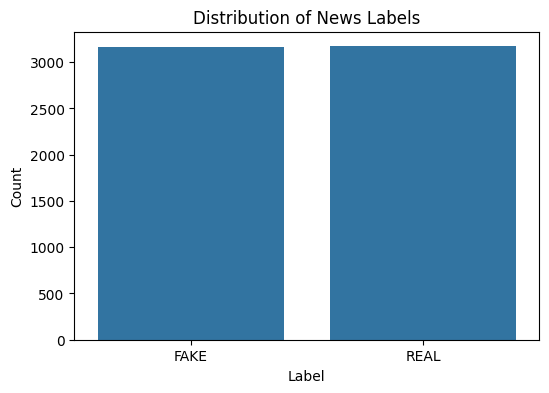

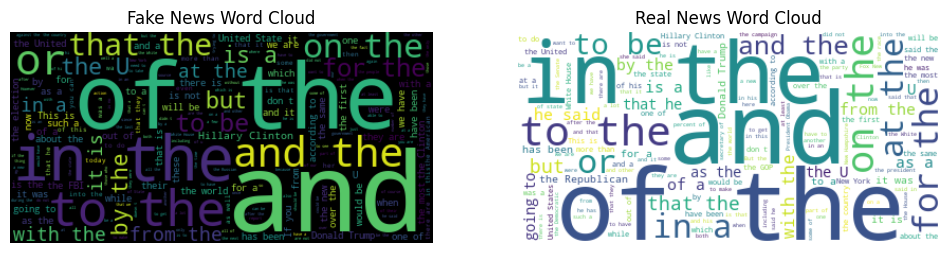

In [6]:

# Exploratory Data Analysis

# Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Distribution of News Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

# Word clouds for fake and real news
fake_text = " ".join(df[df['label'] == 'FAKE']['text'])
real_text = " ".join(df[df['label'] == 'REAL']['text'])

fake_wc = WordCloud(stopwords='english', background_color='black').generate(fake_text)
real_wc = WordCloud(stopwords='english', background_color='white').generate(real_text)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(fake_wc, interpolation='bilinear')
plt.title('Fake News Word Cloud')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(real_wc, interpolation='bilinear')
plt.title('Real News Word Cloud')
plt.axis('off')
plt.show()


In [7]:
# Split the dataset

x_train,x_test,y_train,y_test=train_test_split(df['text'], labels, test_size=0.2, random_state=7)

In [5]:
# #Initialize a TfidfVectorizer
# vectorizeer = TfidfVectorizer(stop_words='english', 
#                               max_df=0.7,
#                               min_df=5,
#                               max_features=1000)

# # Fit and transform the vectorizer on the train set
# trainerx = vectorizeer.fit_transform(x_train)
# print(f"Trainer Matrix shape: {trainerx.shape}")

# # Transform the vectorizer on the test set
# tester = vectorizeer.transform(x_test)
# print(f"Tester Matrix shape: {tester.shape}")

Trainer Matrix shape: (5068, 1000)
Tester Matrix shape: (1267, 1000)


In [8]:
# Find here the function for the above code

def vectorize_text(train_data, test_data, stop_words='english', max_df=0.7):
    """
    Vectorize text data using TF-IDF.
    Args:
        train_data (iterable): Training data (text documents).
        test_data (iterable): Test data (text documents).
        stop_words (str or list): Words to ignore.
        max_df (float): Max document frequency.
        min_df (int): Min document frequency.
        max_features (int): Maximum number of features.

    Returns:
        tuple: TF-IDF transformed train and test matrices, vectorizer object.
    """
    vectorizer = TfidfVectorizer(stop_words=stop_words)
    trainerx = vectorizer.fit_transform(train_data)
    tester = vectorizer.transform(test_data)
    return trainerx, tester, vectorizer

# Call the function to vectorize the data
trainerx, tester, vectorizer = vectorize_text(x_train, x_test)

print(f"Trainer Matrix shape: {trainerx.shape}")
print(f"Tester Matrix shape: {tester.shape}")

#DataFlair - Initialize a PassiveAggressiveClassifier
pac=PassiveAggressiveClassifier(max_iter=70)

pac.fit(trainerx,y_train)

#DataFlair - Predict on the test set and calculate accuracy
y_pred=pac.predict(tester)
score=accuracy_score(y_test,y_pred)
print(f'Accuracy: {round(score*100,2)}%')


Trainer Matrix shape: (5068, 61651)
Tester Matrix shape: (1267, 61651)
Accuracy: 92.74%


In [9]:
#DataFlair - Build confusion matrix
confusion_matrix(y_test,y_pred, labels=['FAKE','REAL'])

array([[587,  51],
       [ 41, 588]], dtype=int64)

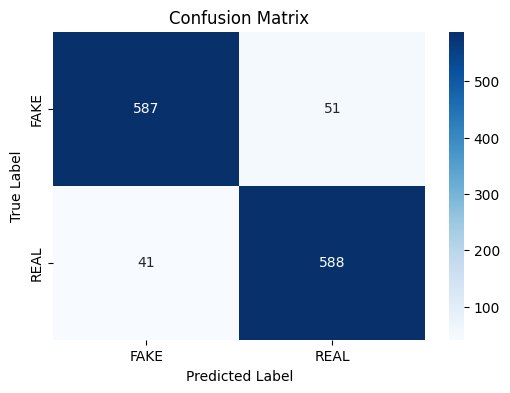

In [10]:

# Confusion Matrix Visualization

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=['FAKE', 'REAL'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



## Conclusions

This notebook demonstrates the power of machine learning in tackling the issue of fake news detection. 
Key insights include:
- The TF-IDF vectorizer effectively transforms text into features for modeling.
- The PassiveAggressiveClassifier achieves impressive accuracy in distinguishing fake and real news.
- Visualizations, like word clouds and confusion matrices, help interpret the results clearly.

### Future Work
- Incorporate more advanced models like deep learning for potentially higher accuracy.
- Explore additional datasets to improve model robustness.
- Develop a real-time system for fake news detection.

Fake news detection is a challenging yet rewarding problem, and machine learning provides a promising approach to addressing it. Let's continue refining these techniques to make a positive impact!
